# Locomotion State — the maths

**What it answers:** is the body moving through space, and how — **stationary / on foot / in vehicle**.

**Honest catch up front:** locomotion is about moving through *space*, but an
accelerometer only sees *body motion*, not displacement. So we read the **motion
signature** (orientation-proof, all from |accel|), not true distance:

- **movement** = std of |accel| — how much the body is moving
- **step rhythm** = autocorrelation peak — does the motion *repeat* (stepping) or not?

**The rule:**

- barely moving → **stationary** (standing / sitting / still in space)
- clear repeating rhythm → **on foot** (walking / running)
- moving but no rhythm → **in vehicle** (passive vibration / steering, no stepping)

**Honest limits** (state them, don't hide them):

- a **smooth vehicle ride looks stationary** (low body motion) — GPS *speed* is what truly separates it
- **moving in place** (fidgeting, chores) looks like in-vehicle — accel can't tell "through space"
- so **"in vehicle" is really a catch-all for "moving but not stepping"** — expect it to be the leakiest class. This is the hardest axis; GPS is what firms it up.

In [1]:
import numpy as np

FS      = 100     # sample rate (Hz)
MOVE_T  = 0.3     # std of |accel| below this = not moving -> stationary
STEP_T  = 0.30    # repeating-rhythm strength above this = on foot

def features(window_xyz):                       # all from |accel| -> orientation-proof
    mag = np.sqrt((window_xyz**2).sum(axis=1))
    movement = mag.std()                        # how much body motion
    m  = mag - mag.mean()
    ac = np.correlate(m, m, mode="full")[len(m)-1:]
    rhythm = 0.0 if ac[0] == 0 else (ac/ac[0])[15:128].max()   # repeat at any step cadence
    return movement, float(rhythm)

def locomotion(window_xyz):                     # the deterministic rule (accelerometer only)
    movement, rhythm = features(window_xyz)
    if movement < MOVE_T:  return "stationary"
    if rhythm > STEP_T:    return "on foot"      # steady stepping = walking / running
    return "in vehicle"                          # moving but not stepping (GPS would confirm)

## Load the data — hand sensor, Protocol + Optional

Locomotion needs a **vehicle** class. PAMAP2 Protocol has the still + on-foot
activities; the **Optional** files add **car driving** — so we combine both. We use
the **hand** sensor (cols 4–6): driving shows up there (steering), but is nearly
invisible on the chest/ankle (those just read a still, seated body).

In [2]:
import pandas as pd, glob

BASE  = "/home/voare/Documents/Synheart/Kinematics/Dataset/PAMAP2_data/PAMAP2_Dataset"
FILES = sorted(glob.glob(BASE+"/Protocol/*.dat")) + sorted(glob.glob(BASE+"/Optional/*.dat"))

NAMES = {1:"lying",2:"sitting",3:"standing",4:"walking",5:"running",
         7:"nordic_walk",11:"driving",12:"ascend_stairs",13:"descend_stairs"}

# peek at one file (col 1 = activity, cols 4,5,6 = hand accel)
d = pd.read_csv(FILES[0], sep=r"\s+", header=None)
print("files:", len(FILES), "(Protocol + Optional)")
d[[1,4,5,6]].rename(columns={1:"activity",4:"acc_x",5:"acc_y",6:"acc_z"}).head()

files: 14 (Protocol + Optional)


,activity,acc_x,acc_y,acc_z
0,0,2.37223,8.60074,3.51048
1,0,2.18837,8.56560,3.66179
2,0,2.37357,8.60107,3.54898
3,0,2.07473,8.52853,3.66021
4,0,2.22936,8.83122,3.70000


## Run the rule on the stream

Slide 5 s windows over the hand signal across every file, run the rule, and keep the
true activity next to each verdict. Driving comes from the Optional files; everything
else from Protocol. We window only inside one activity and skip windows with gaps.

In [3]:
WIN = 500   # 5 s window (100 Hz) — same as the other axes

rows = []
for path in FILES:
    raw = pd.read_csv(path, sep=r"\s+", header=None)
    act = raw[1].to_numpy()
    xyz = raw[[4,5,6]].to_numpy()                  # hand accel
    change = np.where(np.diff(act) != 0)[0] + 1
    for s0, e0 in zip(np.r_[0, change], np.r_[change, len(act)]):
        a = act[s0]
        if a not in NAMES:                         # keep only locomotion-relevant activities
            continue
        for s in range(s0, e0 - WIN + 1, WIN):
            w = xyz[s:s+WIN]
            if np.isnan(w).any():
                continue
            rows.append((NAMES[a], locomotion(w)))

res = pd.DataFrame(rows, columns=["activity", "verdict"])
print("windows:", len(res))
print(res.verdict.value_counts().to_string())
res.head()

windows: 1804
verdict
stationary    810
on foot       547
in vehicle    447


,activity,verdict
0,lying,in vehicle
1,lying,in vehicle
2,lying,in vehicle
3,lying,stationary
4,lying,in vehicle


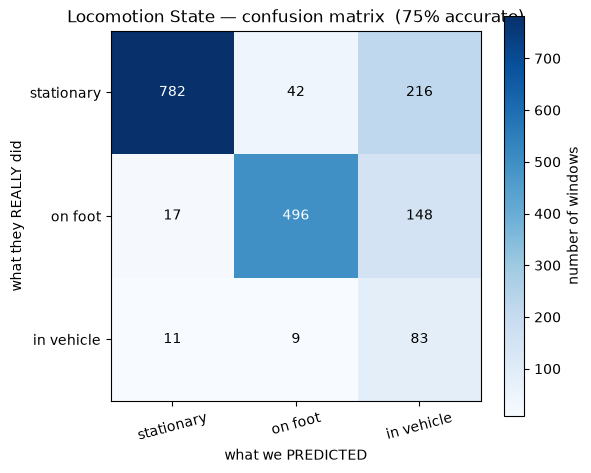

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

true_loco = {"lying":"stationary", "sitting":"stationary", "standing":"stationary",
             "walking":"on foot", "running":"on foot", "nordic_walk":"on foot",
             "ascend_stairs":"on foot", "descend_stairs":"on foot",
             "driving":"in vehicle"}
res["true"] = res.activity.map(true_loco)

labels = ["stationary", "on foot", "in vehicle"]
cm  = confusion_matrix(res["true"], res["verdict"], labels=labels)
acc = (res["true"] == res["verdict"]).mean()

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(3), labels, rotation=15); plt.yticks(range(3), labels)
plt.xlabel("what we PREDICTED")          # x = predicted locomotion
plt.ylabel("what they REALLY did")       # y = true locomotion
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(label="number of windows")
plt.title(f"Locomotion State — confusion matrix  ({acc*100:.0f}% accurate)")
plt.tight_layout(); plt.show()